In [106]:
import pandas as pd

In [107]:
df = pd.read_csv('spam.csv', encoding='latin-1')

In [108]:
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [109]:
df.shape

(5572, 5)

In [110]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [111]:
df

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [112]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)

In [113]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [114]:
## Missing valued data

df.isna().sum()

target    0
text      0
dtype: int64

In [115]:
## duplicate data

df.duplicated().sum()

np.int64(403)

In [116]:
## Droping all duplicates

df.drop_duplicates(keep='first',inplace=True)

In [117]:
df.shape

(5169, 2)

In [118]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [119]:
### Performing  Label Encoding

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

In [120]:
df['target'] = encoder.fit_transform(df['target'])

In [121]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [122]:
## Adding a column with number of characters in the text

df['num_char'] = df['text'].apply(lambda x:len(x))

In [123]:
### Adding a column with number of words in the text

import nltk

df['num_words'] = df['text'].apply(lambda x : len(nltk.word_tokenize(x)))

In [124]:
### Adding a column with number of semtences in the text

df['num_sent'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [125]:
df.head()

,target,text,num_char,num_words,num_sent
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


## EDA

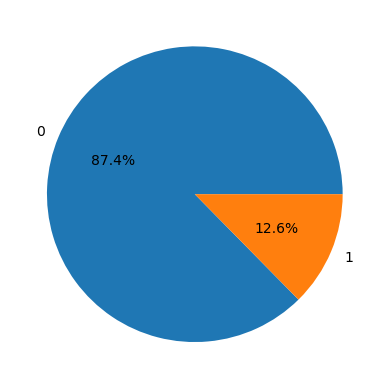

In [126]:
### Number of spam and not spam messages

import seaborn as sns
import matplotlib.pyplot as plt

plt.pie(x=df['target'].value_counts(),labels=df['target'].value_counts().index,autopct='%1.1f%%')
plt.show()

In [127]:
df[['num_char','num_words','num_sent']].describe()

,num_char,num_words,num_sent
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


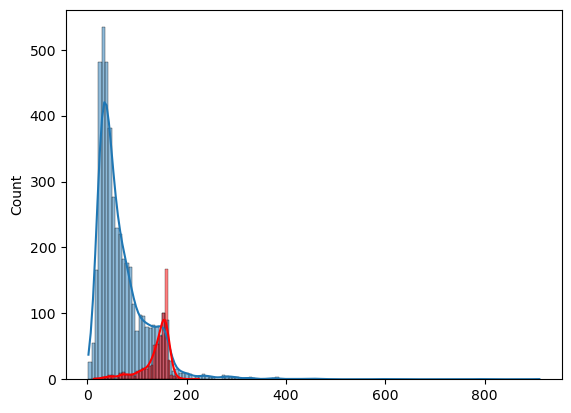

In [128]:
sns.histplot(df[df['target'] == 0]['num_char'].values,kde=True)
sns.histplot(df[df['target'] == 1]['num_char'].values,kde=True,color='red')
plt.show()

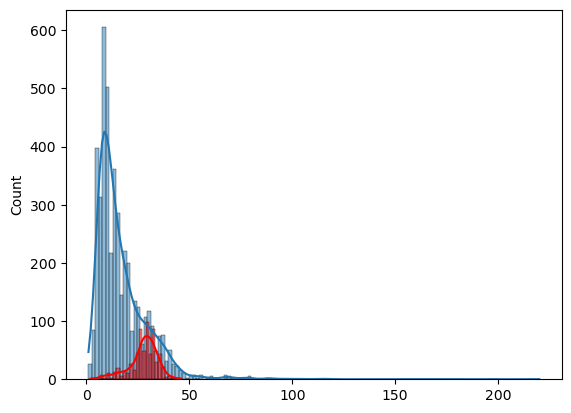

In [129]:
sns.histplot(df[df['target'] == 0]['num_words'].values,kde=True)
sns.histplot(df[df['target'] == 1]['num_words'].values,kde=True,color='red')
plt.show()

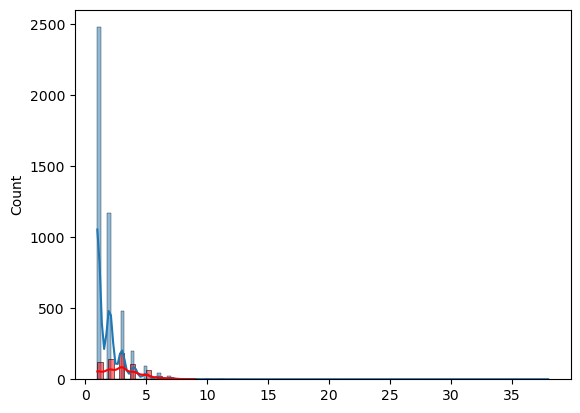

In [130]:
sns.histplot(df[df['target'] == 0]['num_sent'].values,kde=True)
sns.histplot(df[df['target'] == 1]['num_sent'].values,kde=True,color='red')
plt.show()

In [131]:
df.corr(numeric_only='True')

,target,num_char,num_words,num_sent
target,1.000000,0.384717,0.262912,0.263939
num_char,0.384717,1.000000,0.965760,0.624139
num_words,0.262912,0.965760,1.000000,0.679971
num_sent,0.263939,0.624139,0.679971,1.000000


<Axes: >

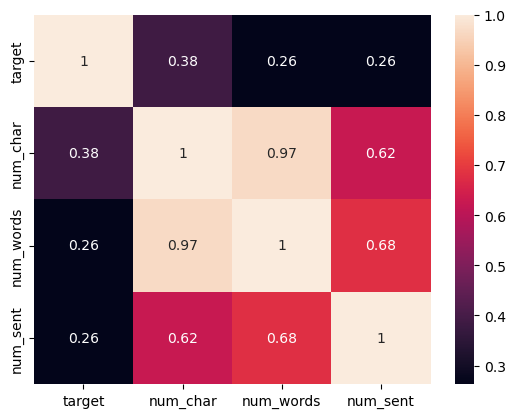

In [132]:
sns.heatmap(df.corr(numeric_only='True'),annot=True)

## Data Preprocessing 
1. Lower Case
2. Tokenize
3. Remove Special Characters
4. Remove Stopwords and Punctuations
5. Stemming or Lemmatization

In [133]:
from nltk.stem import SnowballStemmer
# from nltk.stem import PorterStemmer

stemmer = SnowballStemmer(language='english')
# stemmer = PorterStemmer()

In [134]:
from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Kushagra
[nltk_data]     Satle\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [135]:
import string

In [136]:
def text_tansformation(text) :
    text = text.lower()
    words = nltk.word_tokenize(text)
    words = [word for word in words if word.isalnum()]   ## Removed special characters
    words = [stemmer.stem(word) for word in words if word not in set(stopwords.words('english')) and  word not in set(string.punctuation)]

    return " ".join(words)

In [137]:
text_tansformation(df['text'][10])

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [138]:
df['transformed_text'] = df['text'].apply(text_tansformation)

In [139]:
df.head()

,target,text,num_char,num_words,num_sent,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkts 2...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


## Cheak for top 30 spam words

In [151]:
spam_corpus = []
for message in df[df['target'] == 1]['transformed_text'] :
    spam_corpus.append(message)

spam_corpus = " ".join(spam_corpus)

spam_corpus

'free entri 2 wkli comp win fa cup final tkts 21st may text fa 87121 receiv entri question std txt rate c appli 08452810075over18 freemsg hey darl 3 week word back like fun still tb ok xxx std chgs send rcv winner valu network custom select receivea prize reward claim call claim code kl341 valid 12 hour mobil 11 month u r entitl updat latest colour mobil camera free call mobil updat co free 08002986030 six chanc win cash 100 pound txt csh11 send cost 6day tsandc appli repli hl 4 info urgent 1 week free membership prize jackpot txt word claim 81010 c lccltd pobox 4403ldnw1a7rw18 xxxmobilemovieclub use credit click wap link next txt messag click http england v macedonia dont miss news txt ur nation team 87077 eg england 87077 tri wale scotland poboxox36504w45wq thank subscript rington uk mobil charg pleas confirm repli yes repli charg 07732584351 rodger burn msg tri call repli sms free nokia mobil free camcord pleas call 08000930705 deliveri tomorrow sms ac sptv new jersey devil detroit 

In [152]:
spam_corpus = nltk.word_tokenize(spam_corpus)
spam_corpus

['free',
 'entri',
 '2',
 'wkli',
 'comp',
 'win',
 'fa',
 'cup',
 'final',
 'tkts',
 '21st',
 'may',
 'text',
 'fa',
 '87121',
 'receiv',
 'entri',
 'question',
 'std',
 'txt',
 'rate',
 'c',
 'appli',
 '08452810075over18',
 'freemsg',
 'hey',
 'darl',
 '3',
 'week',
 'word',
 'back',
 'like',
 'fun',
 'still',
 'tb',
 'ok',
 'xxx',
 'std',
 'chgs',
 'send',
 'rcv',
 'winner',
 'valu',
 'network',
 'custom',
 'select',
 'receivea',
 'prize',
 'reward',
 'claim',
 'call',
 'claim',
 'code',
 'kl341',
 'valid',
 '12',
 'hour',
 'mobil',
 '11',
 'month',
 'u',
 'r',
 'entitl',
 'updat',
 'latest',
 'colour',
 'mobil',
 'camera',
 'free',
 'call',
 'mobil',
 'updat',
 'co',
 'free',
 '08002986030',
 'six',
 'chanc',
 'win',
 'cash',
 '100',
 'pound',
 'txt',
 'csh11',
 'send',
 'cost',
 '6day',
 'tsandc',
 'appli',
 'repli',
 'hl',
 '4',
 'info',
 'urgent',
 '1',
 'week',
 'free',
 'membership',
 'prize',
 'jackpot',
 'txt',
 'word',
 'claim',
 '81010',
 'c',
 'lccltd',
 'pobox',
 '4403ld

In [154]:
from collections import Counter

most_common_words = Counter(spam_corpus).most_common(30)

In [156]:
spam_df_words = pd.DataFrame(most_common_words)
spam_df_words

,0,1
0,call,320
1,free,191
2,2,155
3,txt,130
4,text,122
5,u,119
6,ur,119
7,mobil,114
8,stop,104
9,repli,103


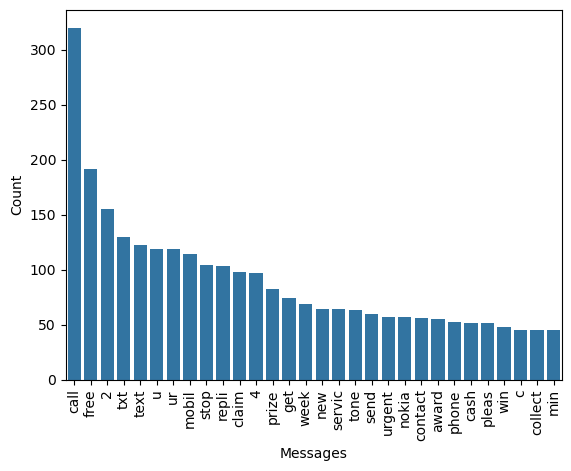

In [160]:
sns.barplot(data=spam_df_words,x=0,y=1)
plt.xticks(rotation=90)
plt.xlabel('Messages')
plt.ylabel('Count')
plt.show()

In [162]:
df.head()

,target,text,num_char,num_words,num_sent,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkts 2...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


## Best Model Selaction and Its Training with Testing

In [163]:
X = df['transformed_text']
y = df['target']

In [164]:
X.shape

(5169,)

In [167]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.20,random_state=42)

In [168]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=2500,ngram_range=(1,2))

In [170]:
X_train_transf = tfidf.fit_transform(X_train)
X_test_transf = tfidf.transform(X_test)

In [176]:
from sklearn.naive_bayes import MultinomialNB,BernoulliNB
from sklearn.metrics import classification_report,accuracy_score,precision_score

In [179]:
models = {
    'Multinomial' : MultinomialNB(),
    'Bernaulli' : BernoulliNB(),
}

for name,algo in models.items() :
    model = algo

    model.fit(X_train_transf,y_train)
    y_pred = model.predict(X_test_transf)

    print("Name : ",name)
    # print(classification_report(y_test,y_pred))
    print("Accuracy Score : ",accuracy_score(y_test,y_pred))
    print("Precision Score : ",precision_score(y_test,y_pred))
    print("\n================================================\n")


Name :  Multinomial
Accuracy Score :  0.971953578336557
Precision Score :  0.9833333333333333


Name :  Bernaulli
Accuracy Score :  0.9777562862669246
Precision Score :  0.9919354838709677




In [181]:
### Performing Hyperparameter Tunning

from sklearn.model_selection import GridSearchCV

mnb_param = {
    'alpha': [0.1, 0.5, 1.0, 1.5, 2.0]
}

bnb_param = {
    'alpha': [0.1, 0.5, 1.0, 1.5, 2.0],
    'fit_prior': [True, False],
    'binarize': [0.0, 0.1, 0.5, 1.0]
}

In [182]:
mnb_model = GridSearchCV(estimator=MultinomialNB(),param_grid=mnb_param,cv=3,n_jobs=-1)
mnb_model.fit(X_train_transf,y_train)

,estimator,MultinomialNB()
,param_grid,"{'alpha': [0.1, 0.5, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.1


In [184]:
bnb_model = GridSearchCV(estimator=BernoulliNB(),param_grid=bnb_param,cv=3,n_jobs=-1)
bnb_model.fit(X_train_transf,y_train)

,estimator,BernoulliNB()
,param_grid,"{'alpha': [0.1, 0.5, ...], 'binarize': [0.0, 0.1, ...], 'fit_prior': [True, False]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.1


In [185]:
print(mnb_model.best_params_)
print(bnb_model.best_params_)

{'alpha': 0.1}
{'alpha': 0.1, 'binarize': 0.0, 'fit_prior': False}


In [186]:
print("MultinomialNB ---> ")
print("Accuracy Score : ",accuracy_score(y_test,mnb_model.predict(X_test_transf)))
print("Precision Score : ",precision_score(y_test,mnb_model.predict(X_test_transf)))

print("BernoulliNB : ")
print("Accuracy Score : ",accuracy_score(y_test,bnb_model.predict(X_test_transf)))
print("Precision Score : ",precision_score(y_test,bnb_model.predict(X_test_transf)))

MultinomialNB ---> 
Accuracy Score :  0.9787234042553191
Precision Score :  0.9624060150375939
BernoulliNB : 
Accuracy Score :  0.9796905222437138
Precision Score :  0.9696969696969697


In [188]:
best_model = bnb_model.best_estimator_

In [ ]:
import pickle

pickle.dump(best_model,open('model.pkl','wb'))
pickle.dump(tfidf,open('vectorizer.pkl','wb'))

In [191]:
pickle.dump(text_tansformation,open('text_transform.pkl','wb'))